In [3]:
import pandas as pd
from pathlib import Path

fm_data = pd.read_csv(base / "data" / "processed" / "clean_fund_master.csv")

for col in ["fund_house", "category", "sub_category", "risk_category"]:
    unique_vals = sorted(fm_data[col].dropna().unique())
    print(f"Unique {col} ({len(unique_vals)}):")
    print(unique_vals)
    print("\n")



Unique fund_house (10):
['Aditya Birla Sun Life MF', 'Axis Mutual Fund', 'DSP Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential MF', 'Kotak Mahindra MF', 'Mirae Asset MF', 'Nippon India MF', 'SBI Mutual Fund', 'UTI Mutual Fund']


Unique category (2):
['Debt', 'Equity']


Unique sub_category (12):
['ELSS', 'Flexi Cap', 'Gilt', 'Index', 'Index/ETF', 'Large & Mid Cap', 'Large Cap', 'Liquid', 'Mid Cap', 'Short Duration', 'Small Cap', 'Value']


Unique risk_category (5):
['High', 'Low', 'Moderate', 'Moderately High', 'Very High']




In [5]:
nav_hist_data = pd.read_csv(base / "data" / "processed" / "clean_nav.csv")

merged = fm_data.merge(nav_hist_data["amfi_code"].drop_duplicates(), on="amfi_code", how="left", indicator=True)
missing = merged[merged["_merge"] == "left_only"]["amfi_code"].drop_duplicates()

print(f"Total unique AMFI codes in fund_master: {merged['amfi_code'].nunique()}")
print(f"AMFI codes missing from nav_history: {len(missing)}")
print(missing.tolist())


Total unique AMFI codes in fund_master: 40
AMFI codes missing from nav_history: 0
[]


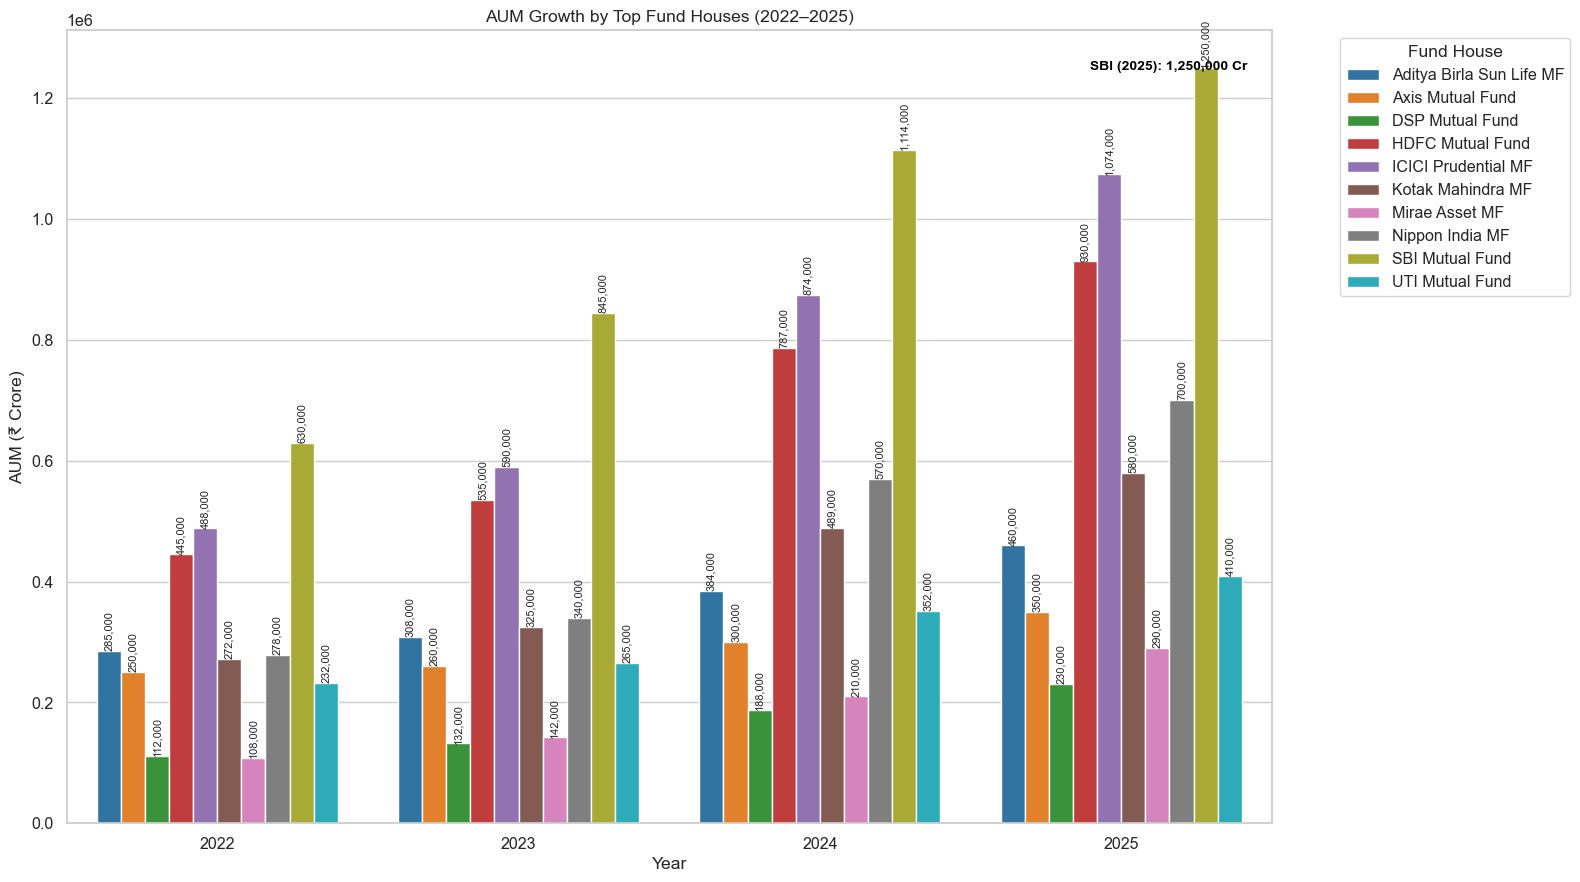

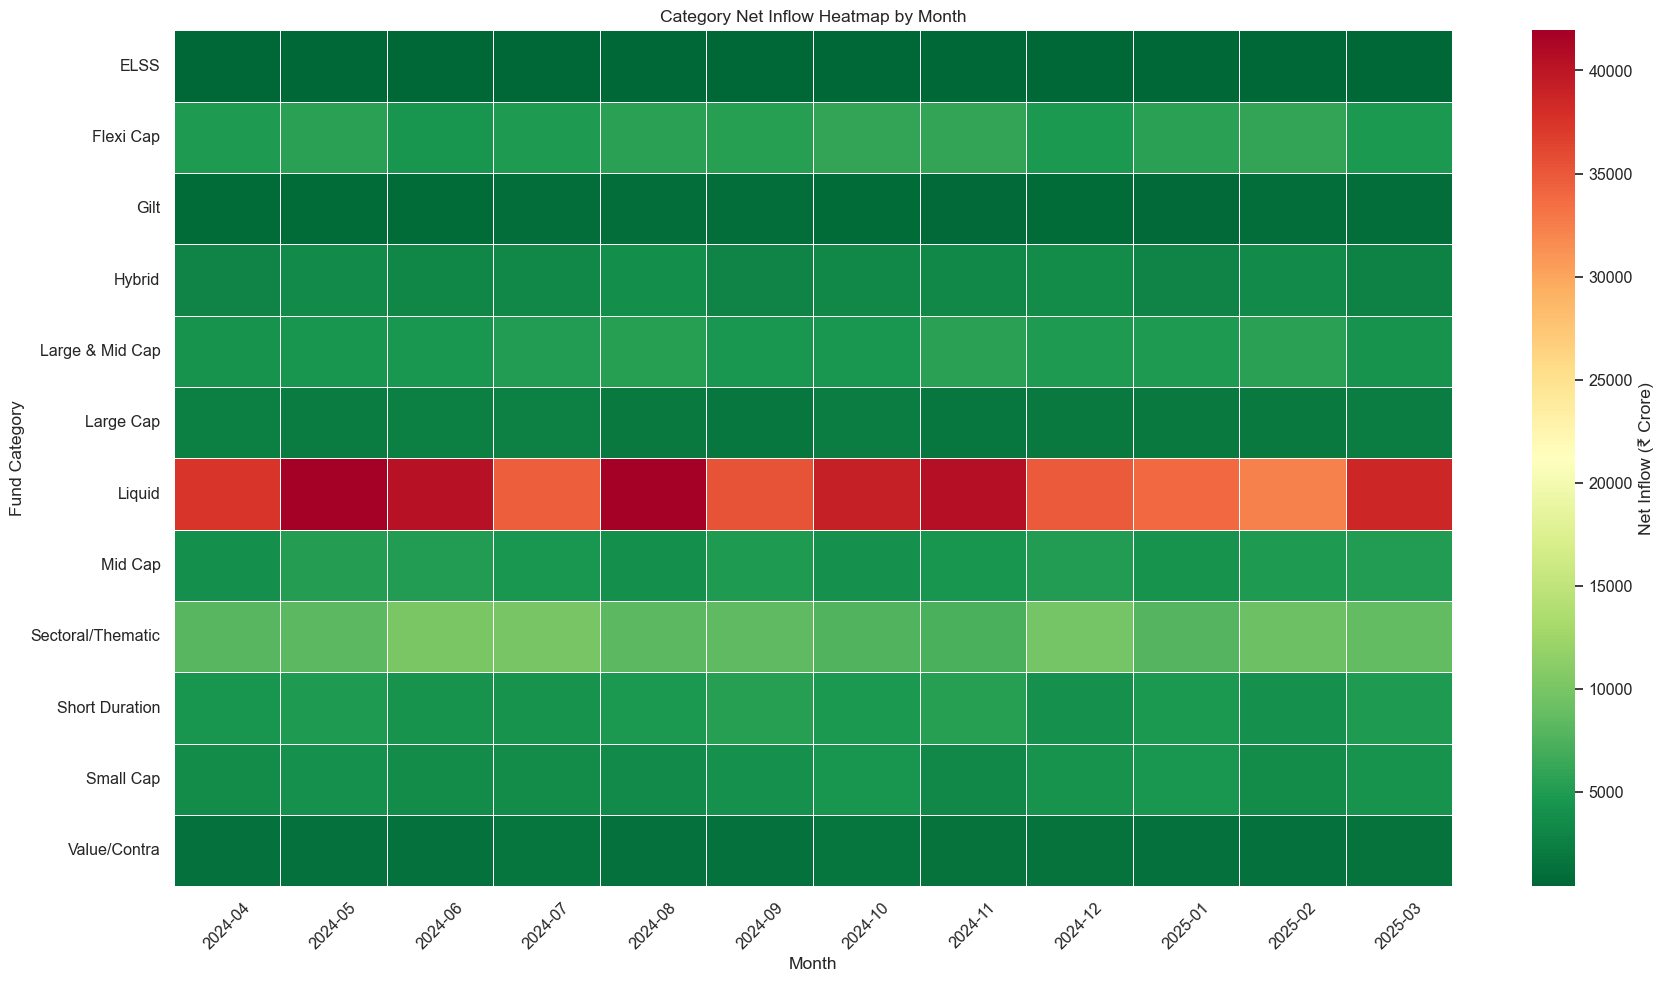

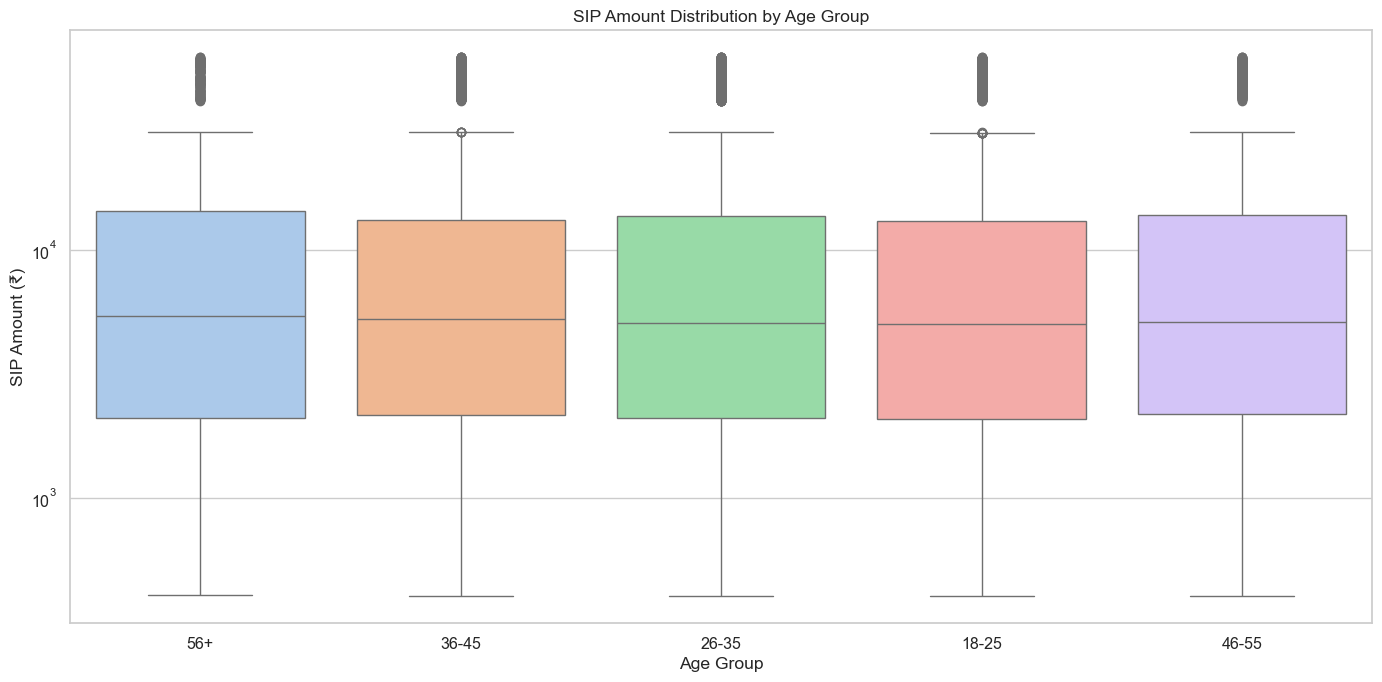

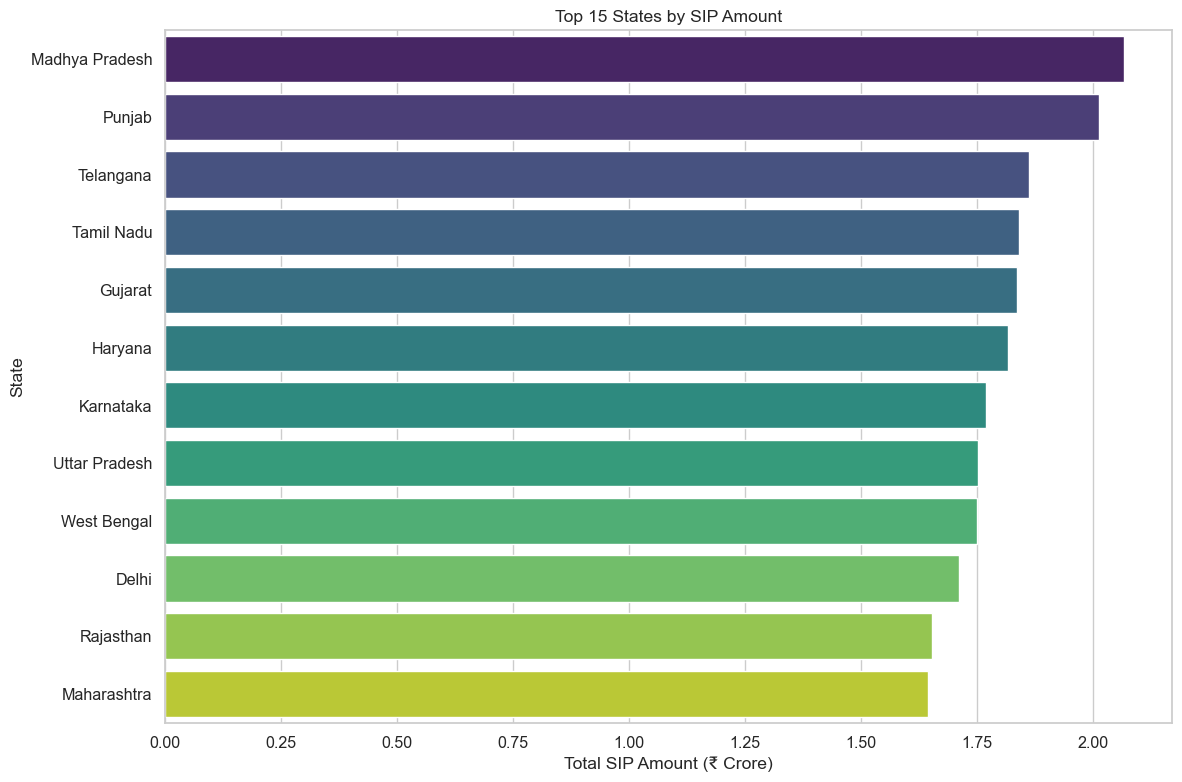

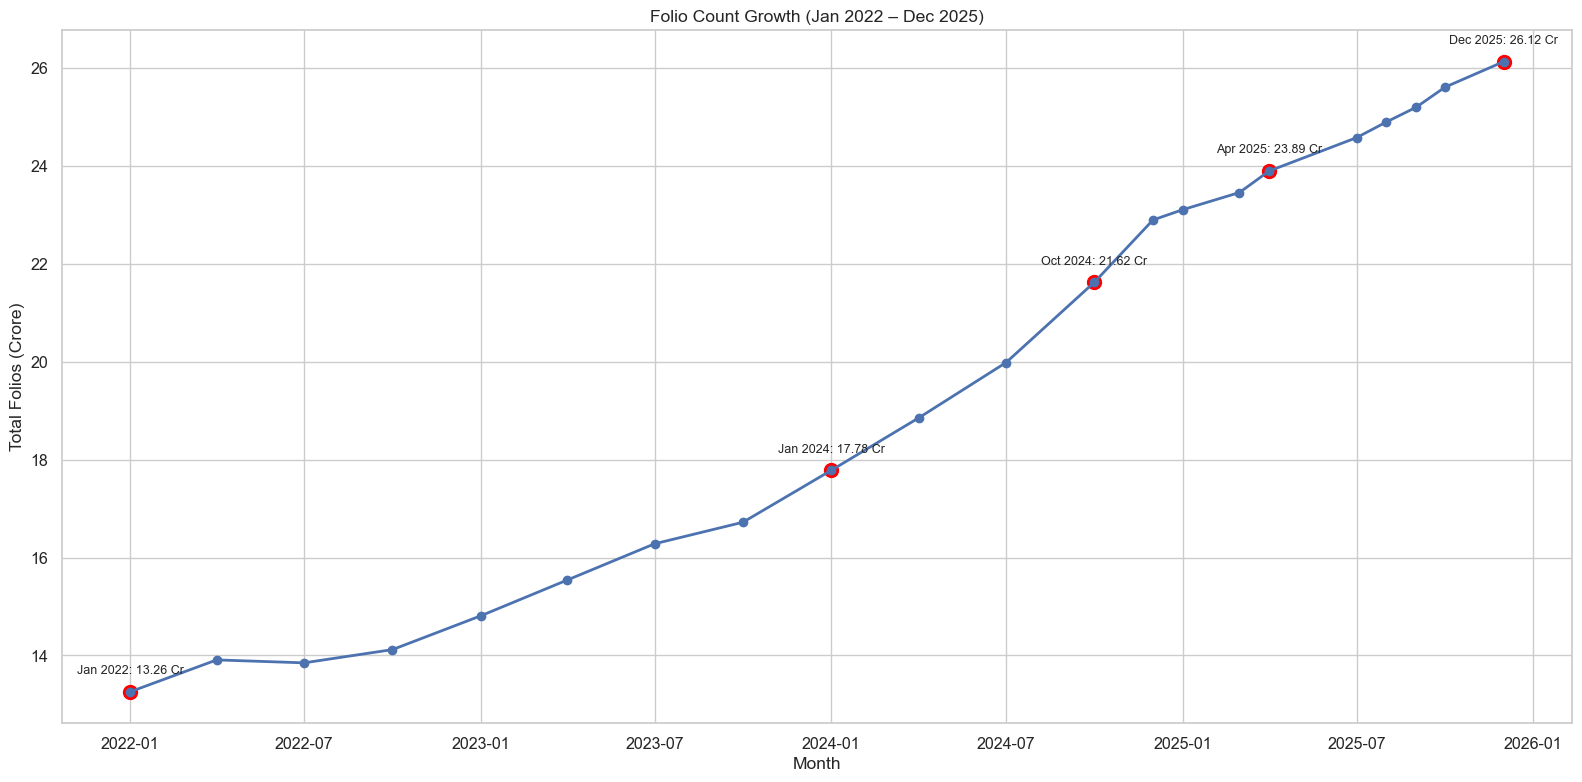

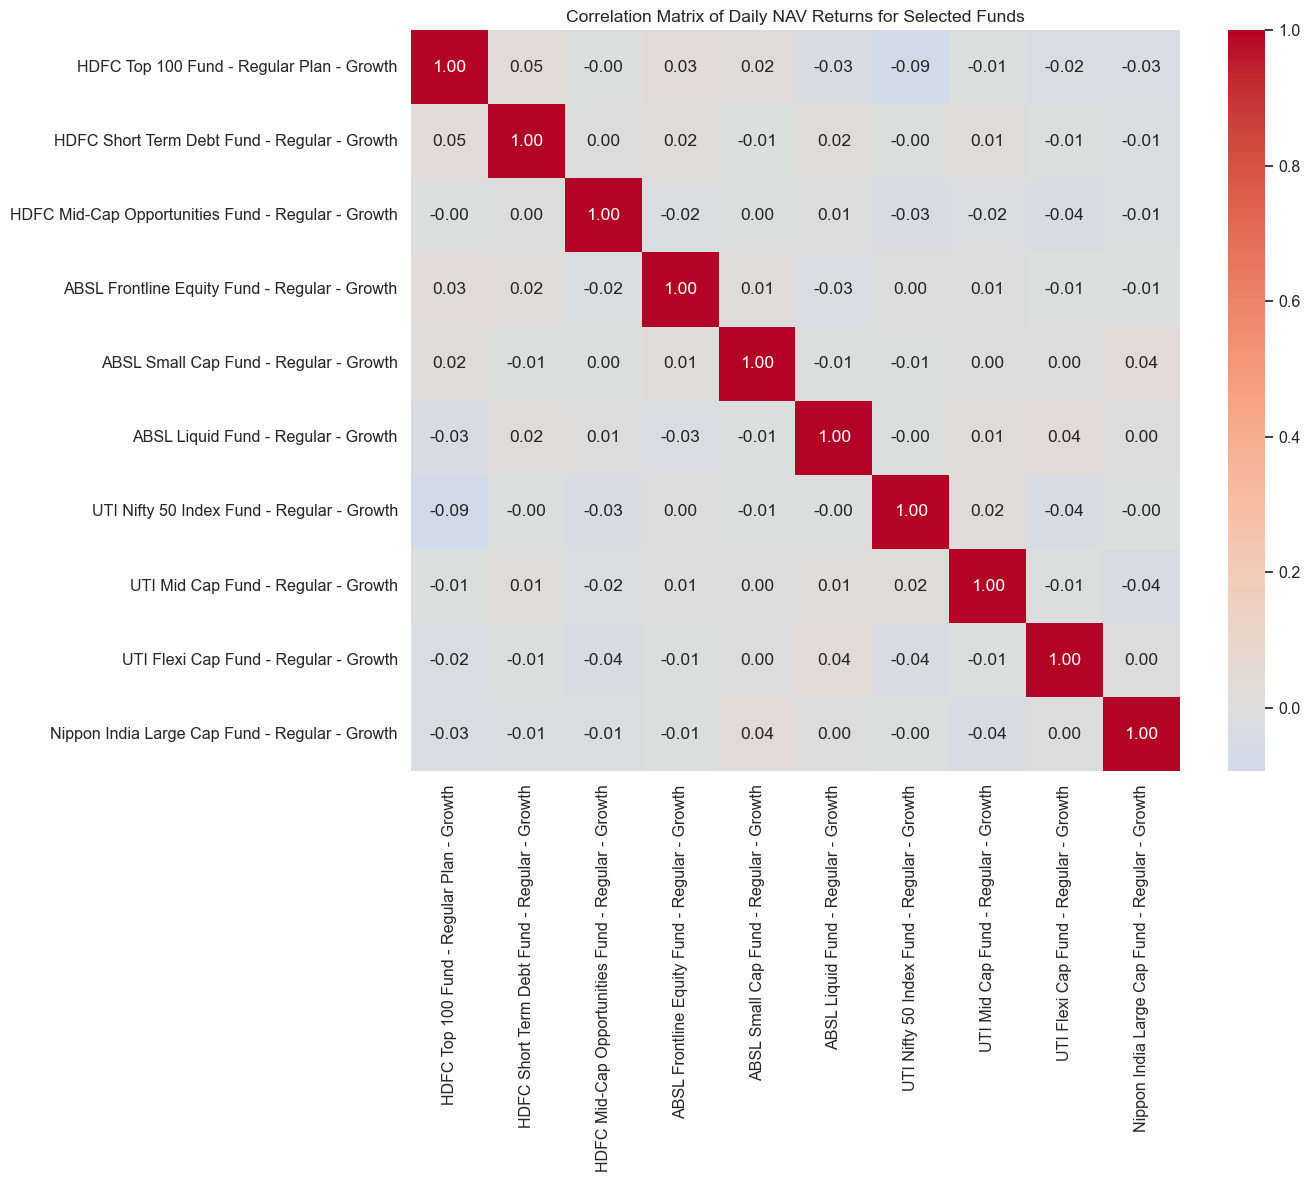

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 7)

# Load files from processed folder only
base = Path.cwd()
if not (base / "data").exists():
    base = base.parent
fm_data = pd.read_csv(base / 'data/processed/clean_fund_master.csv')
nav_data = pd.read_csv(base / 'data/processed/clean_nav.csv', parse_dates=['date'])
aum_data = pd.read_csv(base / 'data/processed/clean_aum.csv', parse_dates=['date'])
sip_data = pd.read_csv(base / 'data/processed/clean_monthly_sip_inflows.csv')
category_data = pd.read_csv(base / 'data/processed/clean_category_inflows.csv')
holdings = pd.read_csv(base / 'data/processed/clean_holdings.csv')
folio = pd.read_csv(base / 'data/processed/clean_folio_count.csv')

transactions_path = base / 'data/processed/clean_transactions.csv'
transactions = pd.read_csv(transactions_path, parse_dates=['transaction_date']) if transactions_path.exists() else None
clean_nav = nav_data.copy()

# 1) NAV trend analysis for 40 schemes 2022–2026
nav_merged = nav_data.merge(fm_data[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
nav_merged = nav_merged[(nav_merged['date'] >= '2022-01-01') & (nav_merged['date'] <= '2026-12-31')]

# select top 40 schemes by holdings market value (if available) else by nav observation count
if 'market_value_cr' in holdings.columns:
    scheme_mv = holdings.groupby('amfi_code')['market_value_cr'].sum().reset_index()
    top_40_codes = scheme_mv.nlargest(40, 'market_value_cr')['amfi_code'].tolist()
else:
    top_40_codes = nav_merged.groupby('amfi_code')['date'].count().nlargest(40).index.tolist()
nav_top40 = nav_merged[nav_merged['amfi_code'].isin(top_40_codes)].copy()

fig_nav = px.line(
    nav_top40,
    x='date',
    y='nav',
    color='scheme_name',
    line_group='scheme_name',
    title='Daily NAV Trend for 40 Selected Schemes (2022–2026)',
    labels={'nav': 'NAV', 'date': 'Date', 'scheme_name': 'Scheme'}
)
fig_nav.update_layout(showlegend=False, height=720)
fig_nav.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.12, line_width=0,
                  annotation_text='2023 Bull Run', annotation_position='top left')
fig_nav.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.12, line_width=0,
                  annotation_text='2024 Market Corrections', annotation_position='top right')
fig_nav.show()

# 2) AUM growth bar chart by fund house for 2022–2025 (top houses only)
aum_data['year'] = aum_data['date'].dt.year
plot_aum = (
    aum_data[aum_data['year'].between(2022, 2025)]
    .groupby(['year', 'fund_house'], as_index=False)
    .agg(aum_crore=('aum_crore', 'max'))
)

# show only top 10 fund houses by 2025 AUM to avoid clutter
top_houses = plot_aum[plot_aum['year'] == 2025].nlargest(10, 'aum_crore')['fund_house'].tolist()
plot_aum_f = plot_aum[plot_aum['fund_house'].isin(top_houses)]

plt.figure(figsize=(16, 9))
ax = sns.barplot(data=plot_aum_f, x='year', y='aum_crore', hue='fund_house', palette='tab10')
ax.set_title('AUM Growth by Top Fund Houses (2022–2025)')
ax.set_ylabel('AUM (₹ Crore)')
ax.set_xlabel('Year')
ax.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8, rotation=90)

# Annotate SBI exact value if present
sbi_val = plot_aum_f[(plot_aum_f['fund_house'] == 'SBI Mutual Fund') & (plot_aum_f['year'] == 2025)]['aum_crore']
if len(sbi_val):
    sbi_val = float(sbi_val.iloc[0])
    plt.annotate(f"SBI (2025): {sbi_val:,.0f} Cr", xy=(0.98, 0.95), xycoords='axes fraction',
                 ha='right', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 3) SIP inflow time-series Jan 2022 – Dec 2025 with annotation
sip_data['month'] = pd.to_datetime(sip_data['month'], format='%Y-%m-%d', errors='coerce')
sip_plot = sip_data[(sip_data['month'] >= '2022-01-01') & (sip_data['month'] <= '2025-12-31')]
fig_sip = px.line(sip_plot, x='month', y='sip_inflow_crore', markers=True,
                  title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
                  labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'})
peak = sip_plot.loc[sip_plot['sip_inflow_crore'].idxmax()]
fig_sip.add_annotation(
    x=peak['month'], y=peak['sip_inflow_crore'],
    text=f"₹{peak['sip_inflow_crore']:,.0f} Cr peak ({peak['month'].strftime('%b %Y')})",
    showarrow=True, arrowhead=2, ay=-40
)
fig_sip.add_hline(y=31002, line_dash='dash', line_color='firebrick',
                  annotation_text='₹31,002 Cr all-time high target', annotation_position='bottom right')
fig_sip.show()

# 4) Category inflow heatmap: months x categories y
category_data['month'] = pd.to_datetime(category_data['month'], errors='coerce')
heat_data = category_data.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')
heat_data = heat_data.sort_index()
if hasattr(heat_data.columns, 'to_series'):
    heat_data.columns = heat_data.columns.to_series().dt.strftime('%Y-%m')
plt.figure(figsize=(18, 10))
sns.heatmap(heat_data, annot=False, cmap='RdYlGn_r', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Net Inflow (₹ Crore)'})
plt.title('Category Net Inflow Heatmap by Month')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5) Investor demographics: age group pie, SIP amount boxplot by age group, gender split
if transactions is not None:
    sip_transactions = transactions[transactions['transaction_type'].str.upper() == 'SIP'].copy()

    age_dist = sip_transactions['age_group'].value_counts().sort_index()
    fig_age = px.pie(names=age_dist.index, values=age_dist.values,
                     title='Investor Age Group Distribution (SIP Transactions)',
                     hole=0.35)
    fig_age.update_traces(textposition='inside', textinfo='percent+label')
    fig_age.show()

    plt.figure(figsize=(14, 7))
    sns.boxplot(data=sip_transactions, x='age_group', y='amount_inr', palette='pastel')
    plt.title('SIP Amount Distribution by Age Group')
    plt.ylabel('SIP Amount (₹)')
    plt.xlabel('Age Group')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

    gender_dist = sip_transactions['gender'].value_counts()
    fig_gender = px.pie(names=gender_dist.index, values=gender_dist.values,
                        title='Gender Split for SIP Investors', hole=0.35)
    fig_gender.update_traces(textposition='inside', textinfo='percent+label')
    fig_gender.show()

    # 6) Geographic distribution: SIP amount by state and T30 vs B30 pie
    state_sip = sip_transactions.groupby('state', as_index=False)['amount_inr'].sum().sort_values('amount_inr', ascending=False).head(15)
    state_sip['amount_cr'] = state_sip['amount_inr'] / 1e7  # convert INR to crore
    plt.figure(figsize=(12, 8))
    sns.barplot(data=state_sip, x='amount_cr', y='state', palette='viridis')
    plt.title('Top 15 States by SIP Amount')
    plt.xlabel('Total SIP Amount (₹ Crore)')
    plt.ylabel('State')
    plt.tight_layout()
    plt.show()

    city_tier = sip_transactions['city_tier'].value_counts()
    fig_tier = px.pie(names=city_tier.index, values=city_tier.values,
                      title='T30 vs B30 SIP Transaction Split', hole=0.4)
    fig_tier.update_traces(textposition='inside', textinfo='percent+label')
    fig_tier.show()
else:
    print('Processed transactions file not found. Investor demographics and geographic SIP charts are skipped.')

# 7) Folio count growth line chart with milestones
folio['month'] = pd.to_datetime(folio['month'], format='%Y-%m')
folio_plot = folio[(folio['month'] >= '2022-01-01') & (folio['month'] <= '2025-12-31')]
plt.figure(figsize=(16, 8))
plt.plot(folio_plot['month'], folio_plot['total_folios_crore'], marker='o', linewidth=2)
plt.title('Folio Count Growth (Jan 2022 – Dec 2025)')
plt.ylabel('Total Folios (Crore)')
plt.xlabel('Month')
for milestone in [13.26, 18.0, 21.0, 24.0, 26.12]:
    closest = folio_plot.iloc[(folio_plot['total_folios_crore'] - milestone).abs().argsort()[:1]]
    if not closest.empty:
        plt.scatter(closest['month'], closest['total_folios_crore'], s=100, c='red')
        plt.text(closest['month'].iloc[0], closest['total_folios_crore'].iloc[0] + 0.3,
                 f"{closest['month'].dt.strftime('%b %Y').iloc[0]}: {closest['total_folios_crore'].iloc[0]:.2f} Cr",
                 ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 8) NAV return correlation matrix for 10 selected funds
clean_nav = clean_nav[(clean_nav['date'] >= '2022-01-01') & (clean_nav['date'] <= '2026-12-31')]
selected_amfi = (
    clean_nav.groupby('amfi_code')['date'].count()
    .nlargest(10)
    .index.tolist()
)
return_data = clean_nav[clean_nav['amfi_code'].isin(selected_amfi)].copy()
return_data['return'] = return_data.groupby('amfi_code')['nav'].pct_change()
return_pivot = return_data.pivot(index='date', columns='amfi_code', values='return')
return_corr = return_pivot.corr()
selected_names = fm_data.set_index('amfi_code').loc[selected_amfi, 'scheme_name'].to_dict()
return_corr.index = [selected_names.get(a, str(a)) for a in return_corr.index]
return_corr.columns = [selected_names.get(a, str(a)) for a in return_corr.columns]
plt.figure(figsize=(14, 12))
sns.heatmap(return_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Daily NAV Returns for Selected Funds')
plt.tight_layout()
plt.show()

# 9) Sector allocation donut from portfolio holdings across equity funds
holdings_eq = holdings.merge(fm_data[['amfi_code', 'category']], on='amfi_code', how='left')
hold_eq = holdings_eq[holdings_eq['category'] == 'Equity'].copy()
sector_mv = (
    hold_eq.groupby('sector', as_index=False)
    .agg(market_value_cr=('market_value_cr', 'sum'))
    .sort_values('market_value_cr', ascending=False)
)
sector_mv['pct'] = sector_mv['market_value_cr'] / sector_mv['market_value_cr'].sum() * 100
fig_sector = px.pie(sector_mv, names='sector', values='market_value_cr', title='Sector Allocation Donut (Equity Portfolio Market Value)', hole=0.45)
fig_sector.update_traces(textinfo='percent+label')
fig_sector.show()


# 10 Key Findings from the Charts:

- **Banking dominates equity allocations**, holding the largest share at **19.3%**, followed by IT (11.8%), Pharma (10.7%), and Automobile (10.6%), indicating a clear preference for financials and cyclical sectors.  
  *(Sector Allocation Donut Chart)*

- **Low correlations** exist between the daily NAV returns of most selected funds, suggesting strong diversification benefits when combining them in a portfolio.  
  *(Correlation Matrix of Daily NAV Returns)*

- **Strong NAV growth** across schemes from 2022–2026, with a notable acceleration in 2025–2026, particularly for top-performing funds that more than doubled in value during the period.  
  *(Daily NAV Trend for 40 Selected Schemes (2022–2026))*

- **SBI Mutual Fund leads AUM growth** among major fund houses, reaching **₹12,50,000 Cr** by 2025, significantly outpacing competitors like HDFC, ICICI Prudential, and Nippon India.  
  *(AUM Growth by Top Fund Houses (2022–2025) Bar Chart)*

- **SIP inflows** have shown consistent upward momentum, rising from ~₹14,000 Cr to a record **₹31,002 Cr** monthly peak in Dec 2025, reflecting robust retail participation.  
  *(Monthly SIP Inflow Trend (Jan 2022 – Dec 2025) Line Chart)*

- **Liquid funds** experienced persistent net outflows, while equity categories like Flexi Cap, ELSS, Mid Cap, and Small Cap recorded steady positive inflows.  
  *(Category Net Inflow Heatmap by Month)*

- **Young investors dominate SIPs**: The **26–35 age group** accounts for **40.9%** of SIP transactions, followed by 36–45 (25%), highlighting strong millennial participation.  
  *(Investor Age Group Distribution (SIP Transactions) Donut Chart)*

- **Gender skew in SIP investing**: Males constitute **66.6%** of SIP investors, while females make up **33.4%**.  
  *(Gender Split for SIP Investors Donut Chart)*

- **Geographic diversification** in SIPs is evident, with **Madhya Pradesh** and **Punjab** leading in total SIP amount, followed by Telangana, Tamil Nadu, and Gujarat — showing strong traction beyond traditional metros.  
  *(Top 15 States by SIP Amount Horizontal Bar Chart)*

- **Total mutual fund folios** grew steadily from 13.25 Cr in Jan 2022 to **26.12 Cr** by Dec 2025, with **T30 cities** still dominating at **66.6%** of folios, though **B30 cities** contribute a healthy **33.4%**.  
  *(Folio Count Growth Line Chart + B30/T30 Donut Chart)*
